<a href="https://colab.research.google.com/github/uide-programacion-inteligencia-mercados/observatorio-g02/blob/main/practica/P1_Colab_Urig%C3%BCen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller Colab · Parcial 1 · Resolver un caso por pasos
**Programación Aplicada a la Inteligencia de Mercados · UIDE · Juan Carlos Correa / Docente**

**Autor:** ___ (tu nombre) · **Fecha:** ___

### Cómo se usa este cuaderno
1. **Archivo → Guardar una copia en Drive.** Trabaja en tu copia, no en este original.
2. Cambia el nombre de arriba a la izquierda por `P1_Colab_TuApellido.ipynb`.
3. Abre en otra pestaña el archivo de código **[CODIGO_P1.txt](https://github.com/uide-programacion-inteligencia-mercados/recursos-curso/blob/main/CODIGO_P1.txt)**. De ahí copias los bloques.
4. Sigue los pasos **en orden**. Antes de cada paso hay un recuadro que dice **qué haces**, **qué debes ver** y **qué hacer si algo sale mal**.
5. Las celdas con ✍️ son para que **tú escribas**: doble clic para editarlas.

**Este taller es el ensayo del examen.** El examen tiene **los mismos pasos y los mismos bloques de código**. Solo cambia el caso: cada uno tendrá el suyo.

## PASO 0 · El caso
**Distribuidora Los Andes** `[SIMULADO]` vende productos de consumo en **Quito** y en **Pasto (Colombia)**. Fija sus precios una vez al año.
El gerente tiene una regla: *si en un país los precios de la economía subieron **más de 10 %** desde 2019, hay que revisar la lista de precios de ese país.*

**Los datos:** Banco Mundial · indicador `FP.CPI.TOTL`, *Índice de precios al consumidor*. Ecuador contra Colombia (`COL`), desde 2019.

**La pregunta del gerente:** ¿en qué país debe revisar su lista de precios, y por qué?

✍️ **Escribe aquí, con tus palabras:** cuál es el problema del gerente y qué vas a medir para responderle (2 o 3 líneas).

El problema: el gerente necesita saber en cuál de los dos países (Ecuador o Colombia) debe revisar su lista de precios, porque su regla dice que si los precios de la economía subieron más de 10 % desde 2019, hay que revisarla.
Qué voy a medir: cuánto cambió el índice de precios al consumidor de Ecuador y de Colombia entre 2019 y el último año disponible, y comparar ese cambio con el umbral de 10 %.

In [ ]:
# ▶ BLOQUE 1 · Preparar las herramientas (no se cambia nada)
import re, time, requests, pandas as pd, matplotlib.pyplot as plt
pd.set_option("display.width", 200)

RECURSOS = "https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/"
AGENTE = {"User-Agent": "ObservatorioUIDE/1.0 (proyecto academico)"}
PAISES = {"ECU": ("Ecuador", "EC"), "COL": ("Colombia", "CO"), "PER": ("Perú", "PE"), "CHL": ("Chile", "CL"),
          "GTM": ("Guatemala", "GT"), "DOM": ("República Dominicana", "DO"), "MEX": ("México", "MX"),
          "BOL": ("Bolivia", "BO"), "USA": ("Estados Unidos", "US")}

def display(tabla):
    """Muestra una tabla como texto simple (sin botones ni filtros)."""
    t = tabla.rename_axis(columns=None)
    if not isinstance(t.index, pd.RangeIndex):
        t = t.reset_index()
    print()
    print(t.to_string(index=False))
    print()

def pedir(url, veces=3, espera=15):
    """Pide una página hasta 3 veces, con paciencia creciente. Si no contesta, devuelve None."""
    for intento in range(1, veces + 1):
        try:
            r = requests.get(url, headers=AGENTE, timeout=espera)
            if r.status_code == 200:
                return r
            print(f"   intento {intento}: la fuente respondió {r.status_code}")
        except Exception as e:
            print(f"   intento {intento}: la fuente está tardando; el robot sigue intentando…")
        if intento < veces:
            time.sleep(2 * intento)
    return None

def traer_banco_mundial(pais_2, indicador, desde):
    """Ecuador y otro país, un indicador, desde un año. Si la API falla, usa el respaldo del profesor."""
    url = (f"https://api.worldbank.org/v2/country/ECU;{pais_2}/indicator/{indicador}"
           f"?format=json&date={desde}:2025&per_page=200")
    print("⏳ Pidiendo los datos al Banco Mundial. Puede tardar hasta 1 minuto: no toques nada.")
    r = pedir(url, veces=2, espera=30)
    filas = []
    if r is not None:
        try:
            for d in r.json()[1]:
                if d["value"] is not None:
                    filas.append({"grupo": PAISES[d["countryiso3code"]][0], "momento": int(d["date"]),
                                  "valor": float(d["value"]), "fuente": "Banco Mundial · API en vivo"})
        except Exception:
            filas = []
    if filas:
        print("✔ Datos recibidos del Banco Mundial (API en vivo)")
    else:
        print("⚠ La API no contestó: uso el RESPALDO del profesor (capturado el 27-sep-2026)")
        t = pd.read_csv(RECURSOS + "respaldo_banco_mundial.csv")
        t = t[t.pais_iso3.isin(["ECU", pais_2]) & (t.indicador == indicador) & (t.anio >= desde)]
        filas = [{"grupo": x.pais, "momento": int(x.anio), "valor": float(x.valor),
                  "fuente": "Banco Mundial · respaldo 27-sep-2026"} for x in t.itertuples()]
    datos = pd.DataFrame(filas).sort_values(["grupo", "momento"]).reset_index(drop=True)
    print(f"   {len(datos)} filas · {datos.grupo.nunique()} países · años {datos.momento.min()} a {datos.momento.max()}")
    print(f"   Para verificar a mano (Paso 3), abre este enlace:")
    print(f"   https://data.worldbank.org/indicator/{indicador}?locations=EC-{PAISES[pais_2][1]}")
    return datos

def precio_en_pagina(html):
    """Busca el precio dentro del código de la ficha, de tres maneras."""
    for patron in (r'product:price:amount" content="([\d.]+)"', r'data-price-amount="([\d.]+)"', r'"price"\s*:\s*"?([\d.]+)'):
        m = re.search(patron, html)
        if m:
            return round(float(m.group(1)), 2)
    return None

def traer_tia(productos, precios_cliente):
    """Precio de hoy en Tía frente al precio del cliente. Si una ficha falla, usa el respaldo del profesor."""
    respaldo = pd.read_csv(RECURSOS + "respaldo_tia.csv").set_index("url")
    filas = []
    for nombre, url in productos.items():
        r = pedir(url, veces=2)
        precio = precio_en_pagina(r.text) if r is not None else None
        if precio is not None:
            origen = "Tía · en vivo"
            print(f"✔ {nombre:<34} Tía hoy USD {precio:.2f}")
            print(f"   {url}")
        elif url in respaldo.index:
            precio = float(respaldo.loc[url, "precio_usd"])
            origen = "Tía · respaldo 27-sep-2026"
            print(f"⚠ {nombre:<34} sin respuesta: uso el respaldo USD {precio:.2f}")
            print(f"   {url}")
        else:
            print(f"✖ {nombre}: sin precio y sin respaldo. Revisa el enlace."); continue
        filas.append({"grupo": nombre, "momento": "1 · Precio del cliente", "valor": precios_cliente[nombre], "fuente": "Cliente [SIMULADO]"})
        filas.append({"grupo": nombre, "momento": "2 · Tía hoy", "valor": precio, "fuente": origen})
        time.sleep(2)                                    # pausa humana: no molestar a la tienda
    datos = pd.DataFrame(filas)
    print(f"   {datos.grupo.nunique()} productos comparados.")
    print("   Para verificar a mano (Paso 3): haz clic en uno de los enlaces de arriba y compara el precio de la página con la tabla.")
    return datos

def traer_curso(archivo):
    """Datos del cliente guardados por el profesor en el repositorio recursos-curso."""
    t = pd.read_csv(RECURSOS + archivo)
    t["fuente"] = "Datos del curso [SIMULADO]"
    print(f"✔ Datos recibidos: {t.cliente.iloc[0]} · {t.unidad.iloc[0]}")
    print(f"   {len(t)} filas · {t.grupo.nunique()} grupos · meses {t.momento.min()} a {t.momento.max()}")
    print(f"   Para verificar a mano (Paso 3), abre este enlace:")
    print(f"   https://github.com/uide-programacion-inteligencia-mercados/recursos-curso/blob/main/{archivo}")
    return t[["grupo", "momento", "valor", "fuente"]]

print("✔ Herramientas listas")
# ■ FIN DEL BLOQUE 1

✔ Herramientas listas


## PASO 2 · Traer los datos
> **Qué haces:** copia el **BLOQUE 2A** (Banco Mundial), pégalo abajo y ejecútalo. Para este caso **no cambias nada**: los valores que trae el bloque ya son los del caso (`COL`, `FP.CPI.TOTL`, `2019`).
>
> **Qué debes ver:** `✔ Datos recibidos…` (o `⚠ … uso el RESPALDO`, que también vale) y una tabla con los datos.
>
> **Si algo sale mal:** si sale `⚠`, no pasa nada: el código usó el respaldo del profesor. Anótalo en tu solución: es parte de la verdad del dato.

In [ ]:
# ▶ BLOQUE 2A · Traer datos del Banco Mundial
PAIS_2 = "COL"              # ◀ CAMBIA: el otro país (código de 3 letras)
INDICADOR = "FP.CPI.TOTL"   # ◀ CAMBIA: el código del indicador de tu caso
DESDE = 2019                # ◀ CAMBIA: el año desde el que comparas

datos = traer_banco_mundial(PAIS_2, INDICADOR, DESDE)
display(datos.pivot(index="momento", columns="grupo", values="valor").round(2))
# ■ FIN DEL BLOQUE 2A


⏳ Pidiendo los datos al Banco Mundial. Puede tardar hasta 1 minuto: no toques nada.
✔ Datos recibidos del Banco Mundial (API en vivo)
   14 filas · 2 países · años 2019 a 2025
   Para verificar a mano (Paso 3), abre este enlace:
   https://data.worldbank.org/indicator/FP.CPI.TOTL?locations=EC-CO

 momento  Colombia  Ecuador
    2019    140.95   124.14
    2020    144.51   123.72
    2021    149.56   123.89
    2022    164.78   128.18
    2023    184.12   131.02
    2024    196.29   133.05
    2025    206.38   133.99



## PASO 3 · Verificar un dato a mano
> **Qué haces:** abre el enlace «Para verificar a mano» que imprimió el Paso 2. Busca **un** valor y compáralo con el de tu tabla. Esto lo haces tú, no la máquina.
>
> **Qué debes ver:** el mismo número (o casi) en la página y en tu tabla.

✍️ **Escribe aquí** (doble clic en esta celda para editarla):

- Dato que verifiqué: _Índice de precios al consumidor de Ecuador, año 2025__
- Valor en la página: _134__ · Valor en mi tabla: _Valor en mi tabla: 133,99__
- Etiqueta: **[VERIFICADO]** si coincide · **[POR VERIFICAR]** si no pude comprobarlo · si no coincide, escribe la diferencia y una posible razón.

## PASO 4 · Analizar: cuánto cambió, gráfico y alerta
> **Qué haces:** copia el **BLOQUE 3** de `CODIGO_P1.txt`, pégalo abajo, cambia `UMBRAL` (el número está en el caso) y escribe tu `TITULO`. Ejecútalo.
>
> **Qué debes ver:** una tabla con `variacion_pct` y `alerta`, un gráfico con tu título y una línea por cada grupo con su variación en %.
>
> **Si algo sale mal:** si dice `name 'datos' is not defined`, primero ejecuta el Paso 2.

Comparación de «2019» a «2025» · umbral ±10 %


   grupo  valor_inicial  valor_final  variacion_pct             alerta
Colombia         140.95       206.38           46.4 ⚠ SUPERA EL UMBRAL
 Ecuador         124.14       133.99            7.9  dentro del umbral



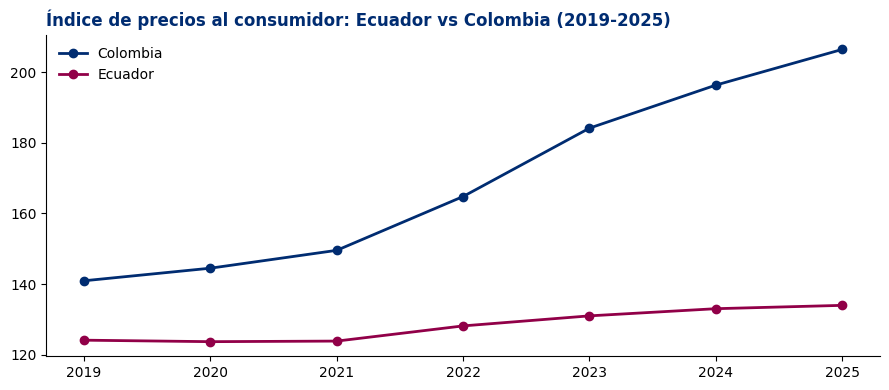

• Colombia: de 140.95 a 206.38 → +46.4 %  (⚠ SUPERA EL UMBRAL)
• Ecuador: de 124.14 a 133.99 → +7.9 %  (dentro del umbral)

Fuente: Banco Mundial · API en vivo


In [ ]:
# ▶ BLOQUE 3 · Analizar: cuánto cambió, gráfico y alerta
UMBRAL = 10                                   # ◀ CAMBIA: la variación (en %) que le importa al cliente
TITULO = "Índice de precios al consumidor: Ecuador vs Colombia (2019-2025)"  # ◀ CAMBIA: el título de tu gráfico

comunes = set.intersection(*[set(d.momento) for _, d in datos.groupby("grupo")])   # solo momentos que tienen todos
d = datos[datos.momento.isin(comunes)]
INICIO, FINAL = min(comunes), max(comunes)
resumen = (d.pivot(index="grupo", columns="momento", values="valor")[[INICIO, FINAL]]
             .rename(columns={INICIO: "valor_inicial", FINAL: "valor_final"}).rename_axis(columns=None))
resumen["variacion_pct"] = ((resumen.valor_final / resumen.valor_inicial - 1) * 100).round(1)
resumen["alerta"] = ["⚠ SUPERA EL UMBRAL" if abs(v) >= UMBRAL else "dentro del umbral" for v in resumen["variacion_pct"]]
resumen = resumen.reset_index()

print(f"Comparación de «{INICIO}» a «{FINAL}» · umbral ±{UMBRAL} %\n")
display(resumen.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
if d.momento.nunique() > 2:
    for (g, s), c in zip(d.groupby("grupo"), ["#002C71", "#910048", "#EAAA00", "#002C38"]):
        ax.plot(s.momento.astype(str), s.valor, marker="o", lw=2, color=c, label=g)
    ax.legend(frameon=False)
else:
    d.pivot(index="grupo", columns="momento", values="valor").plot(kind="bar", ax=ax, rot=0, color=["#002C71", "#910048"])
    ax.legend(frameon=False, title="")
ax.set_title(TITULO, loc="left", weight="bold", color="#002C71")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
for x in resumen.itertuples():
    print(f"• {x.grupo}: de {x.valor_inicial:,.2f} a {x.valor_final:,.2f} → {x.variacion_pct:+.1f} %  ({x.alerta})")
if str(FINAL).startswith("2 · Tía"):
    print("\n  Cómo leerlo: negativo = Tía está MÁS BARATO que el cliente · positivo = Tía está MÁS CARO.")
print(f"\nFuente: {', '.join(d.fuente.unique())}")
# ■ FIN DEL BLOQUE 3

## PASO 5 · Cambiar el programa y volver a ejecutar
> **Qué haces:** En la celda del Paso 4 cambia `UMBRAL = 10` por `UMBRAL = 5` y ejecútala. Luego, en la celda del Paso 2 cambia `DESDE = 2019` por `DESDE = 2022`, y ejecuta el Paso 2 y el Paso 4. Observa qué cambió. **Al final deja `DESDE = 2019` y `UMBRAL = 10`** y vuelve a ejecutar los pasos 2 y 4.
>
> **Qué debes ver:** que las cifras o las alertas cambian cuando cambias un valor. Así compruebas que el programa lo diriges tú.

✍️ **Escribe aquí:** qué cambié, qué pasó con las cifras o las alertas, y por qué crees que pasó (2 o 3 líneas).

Cambié el umbral de 10 a 5 y el año inicial de 2019 a 2022. Con umbral 5 y desde 2019, Ecuador subía 7,9 % y también alertaba. Al comparar desde 2022, Ecuador bajó a +4,5 % y quedó dentro del umbral; Colombia pasó de +46,4 % a +25,2 % y siguió alertando. Pasó porque un período más corto acumula menos inflación, y porque el resultado depende del umbral que elija el gerente.

## PASO 6 · Arreglar el error
> **Qué haces:** copia el **BLOQUE 4**, pégalo abajo y ejecútalo. **Va a fallar a propósito.** Lee la última línea roja, encuentra la palabra mal escrita, corrígela y vuelve a ejecutar.
>
> **Qué debes ver:** primero un error rojo; después de corregirlo, la frase «Lo que más cambió…» y tu tabla.
>
> **Si algo sale mal:** la IA se permite **solo** para entender el error. Si la usas, decláralo en el Paso 7.

In [ ]:
# ▶ BLOQUE 4 · El error a propósito (Paso 6)
# Este bloque FALLA a propósito. Lee la última línea roja, encuentra la palabra
# mal escrita, corrígela y vuelve a ejecutar. Luego explica el error en una línea.
mayor = resumen.loc[resumen["variacion_pct"].abs().idxmax()]
print(f"Lo que más cambió: {mayor.grupo} ({mayor['variacion_pct']:+.1f} %)")
print(resumen)
# ■ FIN DEL BLOQUE 4

Lo que más cambió: Colombia (+46.4 %)
      grupo  valor_inicial  valor_final  variacion_pct              alerta
0  Colombia     140.947850   206.381504           46.4  ⚠ SUPERA EL UMBRAL
1   Ecuador     124.142675   133.993659            7.9   dentro del umbral


✍️ **Escribe aquí:** el error decía _NameError: name 'resumne' is not defined__ · la causa era _la causa era una palabra mal escrita: puse resumne en vez de resumen__ · lo arreglé o arreglé corrigiendo el nombre a resumen.__ (una línea).

## PASO 7 · La solución del caso
Escribe tu respuesta **con cifras de tu tabla**. Doble clic para editar.

**Hallazgo.** Se verifica que _Se verifica que entre 2019 y 2025 el índice de precios al consumidor subió 46,4 % en Colombia (de 140,95 a 206,38) y 7,9 % en Ecuador (de 124,14 a 133,99).__ (por ejemplo: «entre 2019 y 2025 los precios subieron 7,9 % en Ecuador y 46,4 % en Colombia»).

**Respuesta a la pregunta de la Distribuidora.** Hay que revisar la lista de precios de Pasto (Colombia), porque es el único país que supera el umbral de 10 % de la regla del gerente. Quito (Ecuador) queda dentro del umbral

**Recomendación.** Una decisión concreta: __Revisar y actualizar la lista de precios de Pasto en la próxima fijación anual, y volver a medir cuando salga el dato de 2026.

**Lo que el dato todavía no permite afirmar.** _Es un índice de precios de toda la economía, no de los productos de la distribuidora; son solo dos países; y no sabemos si los precios de Pasto ya se habían ajustado durante esos años__

**Etiquetas.** Datos: [VERIFICADO] el valor de Ecuador 2025 (134 en la página, 133,99 en mi tabla); Colombia [POR VERIFICAR] · Cliente: [SIMULADO] · Otras: fuente Banco Mundial, API en vivo (no se usó el respaldo)

**Declaración de uso de IA.** Herramienta: _Claude__ · para qué: _para qué: guiarme paso a paso por el taller (dónde pegar los bloques, qué valores cambiar) y entender el error del Paso 6__ · qué verifiqué yo: qué verifiqué yo: comparé a mano el valor de Ecuador 2025 con la página del Banco Mundial y revisé que las cifras del texto coinciden con mis tablas.___ (o «No usé IA»).

## PASO 8 · Ensayo: las otras dos fuentes
En el examen tu caso puede venir de **Banco Mundial**, de **Tía** o de **datos del curso**. El programa es el mismo: solo cambia el BLOQUE 2. Pruébalo aquí.

**8a · Tía.** Don Luis `[SIMULADO]` tiene una tienda de barrio y quiere saber si Tía le gana en precio. Pega el **BLOQUE 2B** tal como está (ya trae los productos y los precios de Don Luis) y ejecútalo. Luego pega el **BLOQUE 3** con `UMBRAL = 5` y ejecútalo.

In [ ]:
# ▶ BLOQUE 2B · Traer precios de Tía
PRODUCTOS = {               # ◀ CAMBIA: nombre corto y enlace de la ficha de cada producto de tu caso
    "Arroz Mi Rey 2 kg": "https://www.tia.com.ec/supermercado/comestibles/arroz-y-fideos/arroz-mi-rey-2-kg-257950000.html",
    "Leche Toni 1 l": "https://www.tia.com.ec/supermercado/lacteos/leches-blancas/leche-toni-tetrabrik-1-l-entera-337906000.html",
    "Café Nescafé 160 g": "https://www.tia.com.ec/supermercado/comestibles/cafe-y-chocolate-en-polvo/cafe-nescafe-160-g-258247000.html",
}
PRECIOS_CLIENTE = {         # ◀ CAMBIA: el precio del cliente para cada producto (mismo nombre corto)
    "Arroz Mi Rey 2 kg": 3.60,
    "Leche Toni 1 l": 1.60,
    "Café Nescafé 160 g": 8.50,
}

datos = traer_tia(PRODUCTOS, PRECIOS_CLIENTE)
display(datos.pivot(index="grupo", columns="momento", values="valor"))
# ■ FIN DEL BLOQUE 2B

✔ Arroz Mi Rey 2 kg                  Tía hoy USD 3.33
   https://www.tia.com.ec/supermercado/comestibles/arroz-y-fideos/arroz-mi-rey-2-kg-257950000.html
✔ Leche Toni 1 l                     Tía hoy USD 1.65
   https://www.tia.com.ec/supermercado/lacteos/leches-blancas/leche-toni-tetrabrik-1-l-entera-337906000.html
✔ Café Nescafé 160 g                 Tía hoy USD 8.19
   https://www.tia.com.ec/supermercado/comestibles/cafe-y-chocolate-en-polvo/cafe-nescafe-160-g-258247000.html
   3 productos comparados.
   Para verificar a mano (Paso 3): haz clic en uno de los enlaces de arriba y compara el precio de la página con la tabla.

             grupo  1 · Precio del cliente  2 · Tía hoy
 Arroz Mi Rey 2 kg                     3.6         3.33
Café Nescafé 160 g                     8.5         8.19
    Leche Toni 1 l                     1.6         1.65



Comparación de «1 · Precio del cliente» a «2 · Tía hoy» · umbral ±5 %


             grupo  valor_inicial  valor_final  variacion_pct             alerta
 Arroz Mi Rey 2 kg            3.6         3.33           -7.5 ⚠ SUPERA EL UMBRAL
Café Nescafé 160 g            8.5         8.19           -3.6  dentro del umbral
    Leche Toni 1 l            1.6         1.65            3.1  dentro del umbral



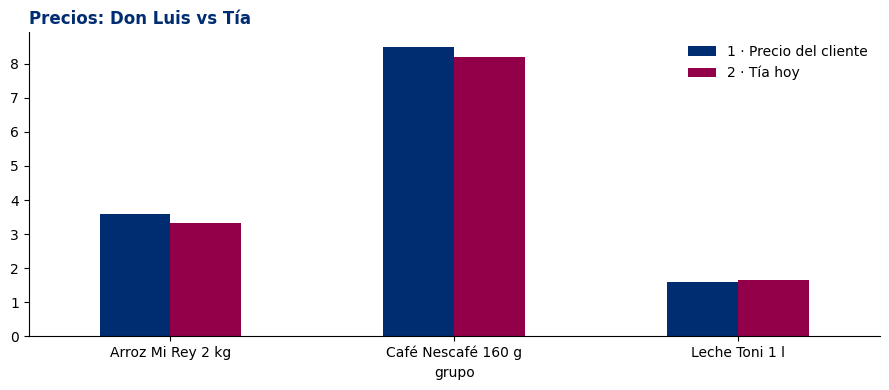

• Arroz Mi Rey 2 kg: de 3.60 a 3.33 → -7.5 %  (⚠ SUPERA EL UMBRAL)
• Café Nescafé 160 g: de 8.50 a 8.19 → -3.6 %  (dentro del umbral)
• Leche Toni 1 l: de 1.60 a 1.65 → +3.1 %  (dentro del umbral)

  Cómo leerlo: negativo = Tía está MÁS BARATO que el cliente · positivo = Tía está MÁS CARO.

Fuente: Cliente [SIMULADO], Tía · en vivo


In [ ]:
# ▶ BLOQUE 3 · Analizar: cuánto cambió, gráfico y alerta
UMBRAL = 5                                   # ◀ CAMBIA: la variación (en %) que le importa al cliente
TITULO = "Precios: Don Luis vs Tía"  # ◀ CAMBIA: el título de tu gráfico

comunes = set.intersection(*[set(d.momento) for _, d in datos.groupby("grupo")])   # solo momentos que tienen todos
d = datos[datos.momento.isin(comunes)]
INICIO, FINAL = min(comunes), max(comunes)
resumen = (d.pivot(index="grupo", columns="momento", values="valor")[[INICIO, FINAL]]
             .rename(columns={INICIO: "valor_inicial", FINAL: "valor_final"}).rename_axis(columns=None))
resumen["variacion_pct"] = ((resumen.valor_final / resumen.valor_inicial - 1) * 100).round(1)
resumen["alerta"] = ["⚠ SUPERA EL UMBRAL" if abs(v) >= UMBRAL else "dentro del umbral" for v in resumen["variacion_pct"]]
resumen = resumen.reset_index()

print(f"Comparación de «{INICIO}» a «{FINAL}» · umbral ±{UMBRAL} %\n")
display(resumen.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
if d.momento.nunique() > 2:
    for (g, s), c in zip(d.groupby("grupo"), ["#002C71", "#910048", "#EAAA00", "#002C38"]):
        ax.plot(s.momento.astype(str), s.valor, marker="o", lw=2, color=c, label=g)
    ax.legend(frameon=False)
else:
    d.pivot(index="grupo", columns="momento", values="valor").plot(kind="bar", ax=ax, rot=0, color=["#002C71", "#910048"])
    ax.legend(frameon=False, title="")
ax.set_title(TITULO, loc="left", weight="bold", color="#002C71")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
for x in resumen.itertuples():
    print(f"• {x.grupo}: de {x.valor_inicial:,.2f} a {x.valor_final:,.2f} → {x.variacion_pct:+.1f} %  ({x.alerta})")
if str(FINAL).startswith("2 · Tía"):
    print("\n  Cómo leerlo: negativo = Tía está MÁS BARATO que el cliente · positivo = Tía está MÁS CARO.")
print(f"\nFuente: {', '.join(d.fuente.unique())}")
# ■ FIN DEL BLOQUE 3

Tía: el arroz Mi Rey de 2 kg está más barato en Tía, 3,33 vs 3,60 (-7,5 %), y es el único que supera el umbral de 5 %. El café también es más barato (-3,6 %), pero la leche cuesta un poco más en Tía (+3,1 %).

In [ ]:
# ▶ BLOQUE 2C · Traer datos del cliente (curso)
ARCHIVO = "curso_taller_panaderia.csv"   # ◀ CAMBIA: el archivo de tu caso

datos = traer_curso(ARCHIVO)
display(datos.pivot(index="momento", columns="grupo", values="valor"))
# ■ FIN DEL BLOQUE 2C

✔ Datos recibidos: Panadería San Blas [SIMULADO] · USD vendidos al mes
   24 filas · 3 grupos · meses 2026-01 a 2026-08
   Para verificar a mano (Paso 3), abre este enlace:
   https://github.com/uide-programacion-inteligencia-mercados/recursos-curso/blob/main/curso_taller_panaderia.csv

momento  Café  Pan  Pasteles
2026-01   950 4200      1800
2026-02   915 4249      1823
2026-03   907 4151      1961
2026-04   920 4408      2044
2026-05   902 4312      2068
2026-06   890 4561      2145
2026-07   866 4587      2280
2026-08   855 4410      2340



Comparación de «2026-01» a «2026-08» · umbral ±10 %


   grupo  valor_inicial  valor_final  variacion_pct             alerta
    Café            950          855          -10.0 ⚠ SUPERA EL UMBRAL
     Pan           4200         4410            5.0  dentro del umbral
Pasteles           1800         2340           30.0 ⚠ SUPERA EL UMBRAL



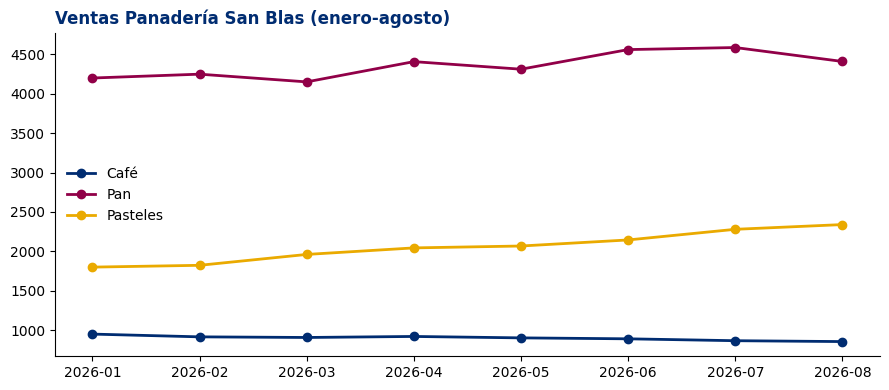

• Café: de 950.00 a 855.00 → -10.0 %  (⚠ SUPERA EL UMBRAL)
• Pan: de 4,200.00 a 4,410.00 → +5.0 %  (dentro del umbral)
• Pasteles: de 1,800.00 a 2,340.00 → +30.0 %  (⚠ SUPERA EL UMBRAL)

Fuente: Datos del curso [SIMULADO]


In [ ]:
# ▶ BLOQUE 3 · Analizar: cuánto cambió, gráfico y alerta
UMBRAL = 10                                   # ◀ CAMBIA: la variación (en %) que le importa al cliente
TITULO = "Ventas Panadería San Blas (enero-agosto)"  # ◀ CAMBIA: el título de tu gráfico

comunes = set.intersection(*[set(d.momento) for _, d in datos.groupby("grupo")])   # solo momentos que tienen todos
d = datos[datos.momento.isin(comunes)]
INICIO, FINAL = min(comunes), max(comunes)
resumen = (d.pivot(index="grupo", columns="momento", values="valor")[[INICIO, FINAL]]
             .rename(columns={INICIO: "valor_inicial", FINAL: "valor_final"}).rename_axis(columns=None))
resumen["variacion_pct"] = ((resumen.valor_final / resumen.valor_inicial - 1) * 100).round(1)
resumen["alerta"] = ["⚠ SUPERA EL UMBRAL" if abs(v) >= UMBRAL else "dentro del umbral" for v in resumen["variacion_pct"]]
resumen = resumen.reset_index()

print(f"Comparación de «{INICIO}» a «{FINAL}» · umbral ±{UMBRAL} %\n")
display(resumen.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
if d.momento.nunique() > 2:
    for (g, s), c in zip(d.groupby("grupo"), ["#002C71", "#910048", "#EAAA00", "#002C38"]):
        ax.plot(s.momento.astype(str), s.valor, marker="o", lw=2, color=c, label=g)
    ax.legend(frameon=False)
else:
    d.pivot(index="grupo", columns="momento", values="valor").plot(kind="bar", ax=ax, rot=0, color=["#002C71", "#910048"])
    ax.legend(frameon=False, title="")
ax.set_title(TITULO, loc="left", weight="bold", color="#002C71")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
for x in resumen.itertuples():
    print(f"• {x.grupo}: de {x.valor_inicial:,.2f} a {x.valor_final:,.2f} → {x.variacion_pct:+.1f} %  ({x.alerta})")
if str(FINAL).startswith("2 · Tía"):
    print("\n  Cómo leerlo: negativo = Tía está MÁS BARATO que el cliente · positivo = Tía está MÁS CARO.")
print(f"\nFuente: {', '.join(d.fuente.unique())}")
# ■ FIN DEL BLOQUE 3

✍️ **Escribe aquí** (una línea por fuente):
- Tía: ¿en qué producto Tía está más barato que Don Luis, y por cuánto? __El arroz Mi Rey de 2 kg: 3,33 en Tía contra 3,60 de Don Luis (-7,5 %). El café también es más barato (-3,6 %), pero la leche cuesta un poco más en Tía (+3,1 %)_
- Panadería: ¿qué producto creció más y cuál cayó? _Los pasteles crecieron más (+30,0 %, de 1.800 a 2.340) y el café cayó (-10,0 %, de 950 a 855). El pan subió +5,0 %.__

## PASO 9 · Guardar y entregar
1. **Entorno de ejecución → Ejecutar todas.** Revisa que ningún paso quede en rojo.
2. **Archivo → Guardar una copia en GitHub** → tu repositorio **personal** → nombre `P1_Colab_TuApellido.ipynb` → Aceptar.
3. Otra vez **Archivo → Guardar una copia en GitHub** → repositorio `uide-programacion-inteligencia-mercados/observatorio-g0X` (tu casa) → ruta `practica/P1_Colab_TuApellido.ipynb` → Aceptar.
   *Si tu casa no aparece:* **Archivo → Descargar → .ipynb**, y en GitHub entra a tu casa → carpeta `practica` → **Add file → Upload files** → arrastra el archivo → **Commit changes**.
4. **Archivo → Imprimir → Guardar como PDF.**
5. En Canvas entregas: el **PDF** y el **enlace** al cuaderno en tu GitHub personal.